In [1]:
from simfile import SimFile
from simulation import Simulation
from validation import switchOffAllEffects, aberration, equatorial2galactic, galactic2equatorial
import os
import numpy as np
import matplotlib.pyplot as plt
import math

In [2]:
sim = Simulation("Jitter")
switchOffAllEffects(sim)
sim["ObservingParameters/NumExposures"] = 1
sim.outputDir = os.environ["PLATO_WORKDIR"]

starCatalogFilename = os.environ["PLATO_WORKDIR"] + "generatedFromPixelCoordinates.starcat"

position = 4000
dim = 100
numSubPixels = sim["SubField/SubPixels"]

sim.createStarCatalogFileFromPixelCoordinates(np.array([position]), np.array([position]), np.array([12.5]), np.array([1]), starCatalogFilename)
sim["ObservingParameters/StarCatalogFile"] = starCatalogFilename

sim["SubField/NumRows"] = dim
sim["SubField/NumColumns"] = dim
sim["SubField/ZeroPointRow"] = position - dim // 2
sim["SubField/ZeroPointColumn"] = position - dim // 2
    

sim["PSF/Model"] = "MappedGaussian"
sim["CCD/IncludeConvolution"] = "yes"

sim["Platform/UseJitter"] = "yes"
sim["Platform/UseJitterFromFile"] = "yes"

In [3]:
jitterTimeScale = 0.1
jitter = 50

numJitterSteps = int(25 / jitterTimeScale) * 500
time = np.arange(numJitterSteps) * jitterTimeScale
noChange = np.zeros(numJitterSteps)
change = np.arange(numJitterSteps) * jitter

jitterFilenameYaw = os.environ["PLATO_WORKDIR"] + "yawJitter.txt"
jitterFilenamePitch = os.environ["PLATO_WORKDIR"] + "pitchJitter.txt"
jitterFilenameRoll = os.environ["PLATO_WORKDIR"] + "rollJitter.txt"

np.savetxt(jitterFilenameYaw, np.c_[time, change, noChange, noChange])
np.savetxt(jitterFilenamePitch, np.c_[time, noChange, change, noChange])
np.savetxt(jitterFilenameRoll, np.c_[time, noChange, noChange, change])

sim["ControlHDF5Content/WriteStarPositions"] = "yes"

In [4]:
jitter2 = jitter

jitterTimeScale2 = 25
numJitterSteps2 = int(25 / jitterTimeScale2) * 500
time2 = np.arange(numJitterSteps2) * jitterTimeScale2
noChange2 = np.zeros(numJitterSteps2)
change2 = np.arange(numJitterSteps2) * jitter2

jitterFilenameYaw2 = os.environ["PLATO_WORKDIR"] + "yawJitter2.txt"
jitterFilenamePitch2 = os.environ["PLATO_WORKDIR"] + "pitchJitter2.txt"
jitterFilenameRoll2 = os.environ["PLATO_WORKDIR"] + "rollJitter2.txt"

np.savetxt(jitterFilenameYaw2, np.c_[time2, change2, noChange2, noChange2])
np.savetxt(jitterFilenamePitch2, np.c_[time2, noChange2, change2, noChange2])
np.savetxt(jitterFilenameRoll2, np.c_[time2, noChange2, noChange2, change2])

# Change in yaw only (exaggerated)

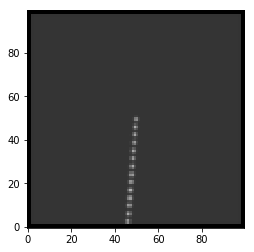

In [5]:
sim["Platform/JitterFileName"] = jitterFilenameYaw
numExposures = 1
sim["ObservingParameters/NumExposures"] = numExposures

output = sim.run(removeOutputFile = True)

im = output.getImage(0)
plt.imshow(im, origin = "lower", cmap='gray', vmin = 5800, vmax = 6100)

In [6]:
sim["Platform/JitterFileName"] = jitterFilenameYaw2

numExposures = 100
sim["ObservingParameters/NumExposures"] = numExposures

output = sim.run(removeOutputFile = True)

Error: SimfFile.getStarCoordinates(): Exposure000014 not in hdf5 file


Text(0, 0.5, 'y [pixels]')

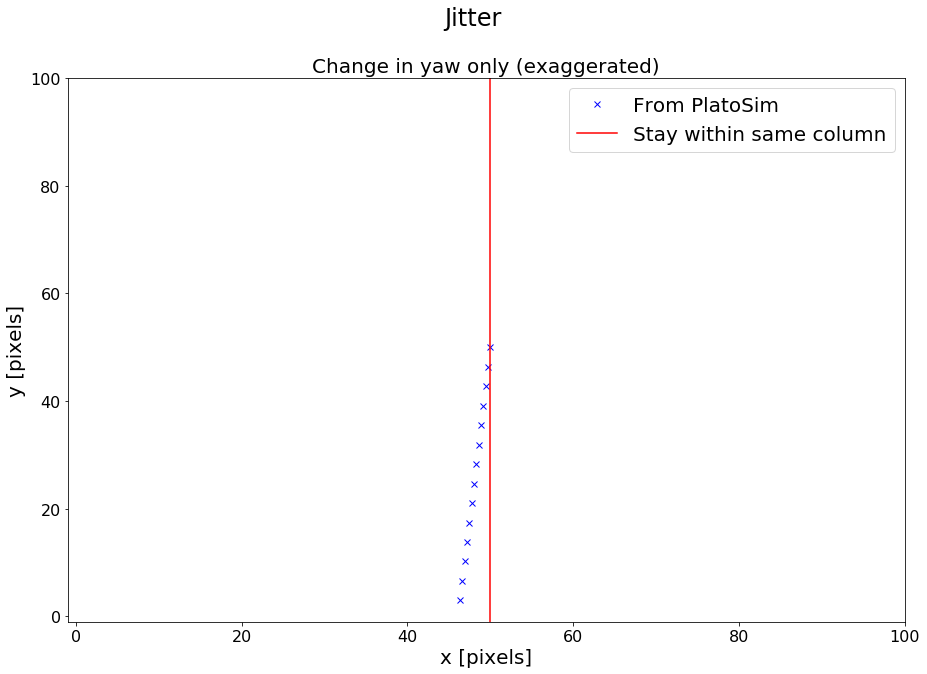

In [7]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

rows = np.array([])
columns = np.array([])

for exposure in range(numExposures):
    try:
        ([row], [column]) = output.getStarCoordinates(exposure)[1:3]
        rows = np.append(rows, row)
        columns = np.append(columns, column)
    except:
        break

plt.plot(columns, rows, "bx", label = "From PlatoSim")

    
    
###############
# Change in row
###############

plt.axvline(x = dim / 2, color = "r", label = "Stay within same column")



########
# Layout
########

plt.xlim([-1, dim])
plt.ylim([-1, dim])

plt.suptitle("Jitter", fontsize = 24)
plt.title("Change in yaw only (exaggerated)", fontsize = 20)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("x [pixels]", fontsize = 20)
plt.ylabel("y [pixels]", fontsize = 20)

# Change in pitch only (exaggerated)

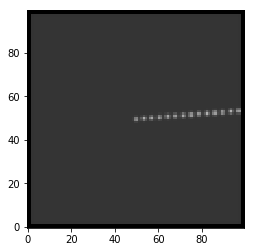

In [8]:
sim["Platform/JitterFileName"] = jitterFilenamePitch

numExposures = 1
sim["ObservingParameters/NumExposures"] = numExposures
output = sim.run(removeOutputFile = True)

im = output.getImage(0)
plt.imshow(im, origin = "lower", cmap='gray', vmin = 5800, vmax = 6100)

In [9]:
sim["Platform/JitterFileName"] = jitterFilenamePitch2

numExposures = 100
sim["ObservingParameters/NumExposures"] = numExposures

output = sim.run(removeOutputFile = True)

Error: SimfFile.getStarCoordinates(): Exposure000014 not in hdf5 file


Text(0, 0.5, 'y [pixels]')

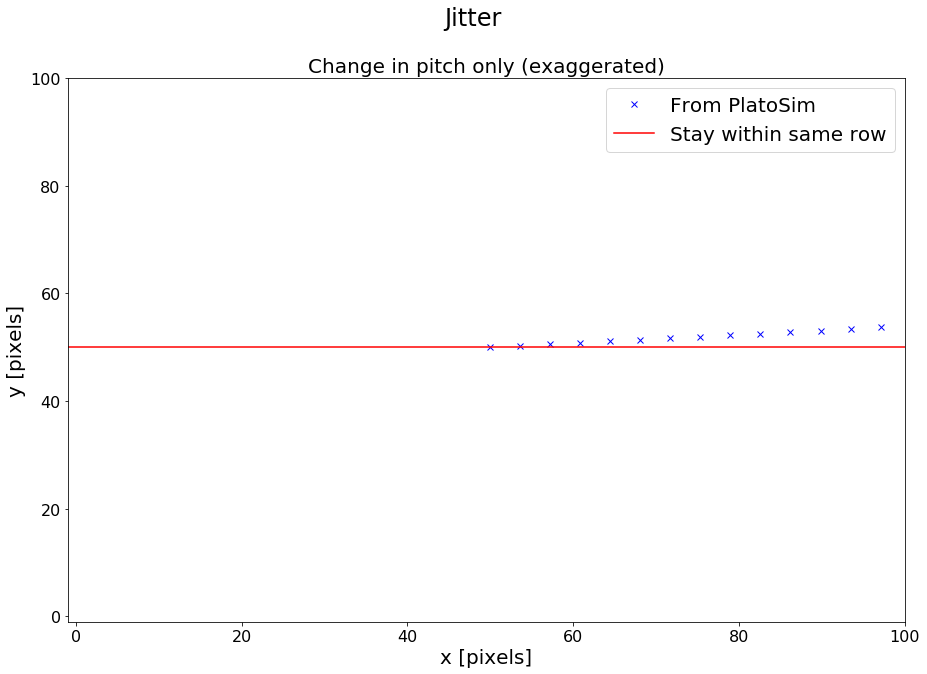

In [10]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

rows = np.array([])
columns = np.array([])

for exposure in range(numExposures):
    try:
        ([row], [column]) = output.getStarCoordinates(exposure)[1:3]
        rows = np.append(rows, row)
        columns = np.append(columns, column)
    except:
        break

plt.plot(columns, rows, "bx", label = "From PlatoSim")



##################
# Change in column
##################

plt.axhline(y = 50, color = "r", label = "Stay within same row")

    
    
########
# Layout
########

plt.xlim([-1, dim])
plt.ylim([-1, dim])

plt.suptitle("Jitter", fontsize = 24)
plt.title("Change in pitch only (exaggerated)", fontsize = 20)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("x [pixels]", fontsize = 20)
plt.ylabel("y [pixels]", fontsize = 20)

# Change in roll only (exaggerated)

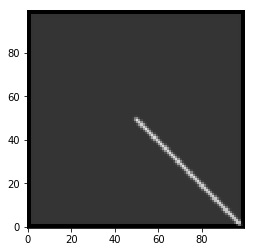

In [11]:
sim["Platform/JitterFileName"] = jitterFilenameRoll

numExposures = 1
sim["ObservingParameters/NumExposures"] = numExposures
output = sim.run(removeOutputFile = True)

im = output.getImage(0)
plt.imshow(im, origin = "lower", cmap='gray', vmin = 5800, vmax = 6100)

In [12]:
sim["Platform/JitterFileName"] = jitterFilenameRoll2

numExposures = 100
sim["ObservingParameters/NumExposures"] = numExposures

output = sim.run(removeOutputFile = True)

Error: SimfFile.getStarCoordinates(): Exposure000052 not in hdf5 file


Text(0, 0.5, '$y_{CCD} [pixels]$')

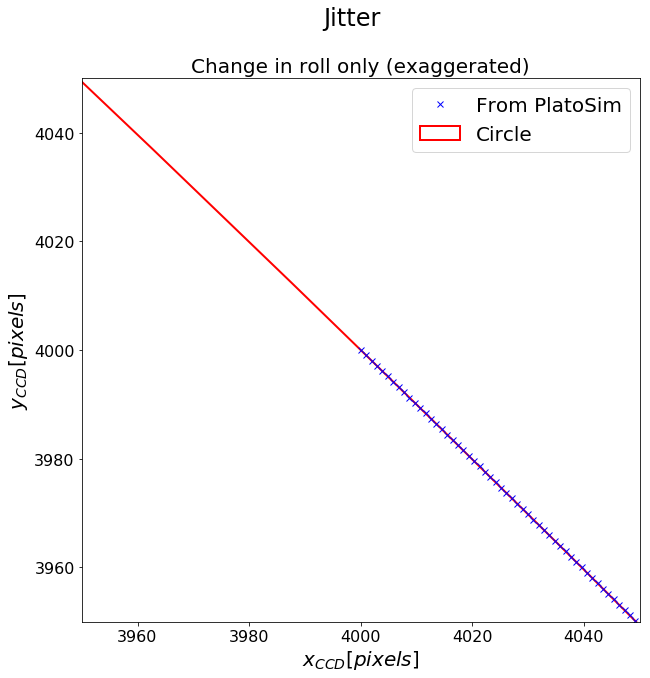

In [13]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

rows = np.array([])
columns = np.array([])

for exposure in range(numExposures):
    try:
        ([row], [column]) = output.getStarCoordinates(exposure)[1:3]
        rows = np.append(rows, row)
        columns = np.append(columns, column)
    except:
        break

plt.plot(columns + position - dim//2, rows + position - dim//2, "bx", label = "From PlatoSim")



##################
# Change in column
##################

radiusSquared = 2 * (position**2)
circ = plt.Circle((0,0), radius = math.sqrt(radiusSquared), color = "white", linewidth = 2, label = "Circle")
ax.add_patch(circ)
circ.set_edgecolor("r")
circ.set_facecolor("none")

    
    
########
# Layout
########

plt.xlim([position - 50, position + 50])
plt.ylim([position - 50, position + 50])

plt.suptitle("Jitter", fontsize = 24)
plt.title("Change in roll only (exaggerated)", fontsize = 20)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("$x_{CCD} [pixels]$", fontsize = 20)
plt.ylabel("$y_{CCD} [pixels]$", fontsize = 20)

# Auto-generated TED

In [23]:
sim["Platform/UseJitterFromFile"] = "no"

# rmsYaw = 2.0
# rmsPitch = 3.0
# rmsRoll = 4.0

sim["Platform/JitterYawRms"] = rmsYaw
sim["Platform/JitterPitchRms"] = rmsPitch
sim["Platform/JitterRollRms"] = rmsRoll

sim["SubField/NumRows"] = 1
sim["SubField/NumColumns"] = 1

numExposures = 5000
sim["ObservingParameters/NumExposures"] = numExposures
output = sim.run(removeOutputFile = True)


2019-05-28 12:17:51 WARNING Simulation: no information about detected stars to write to HDF5
2019-05-28 12:17:51 WARNING Camera: No star positions to write to HDF5 file.



### Yaw

In [24]:
yaw, pitch, roll = output.getYawPitchRoll()

Text(0, 0.5, 'Yaw [degrees]')

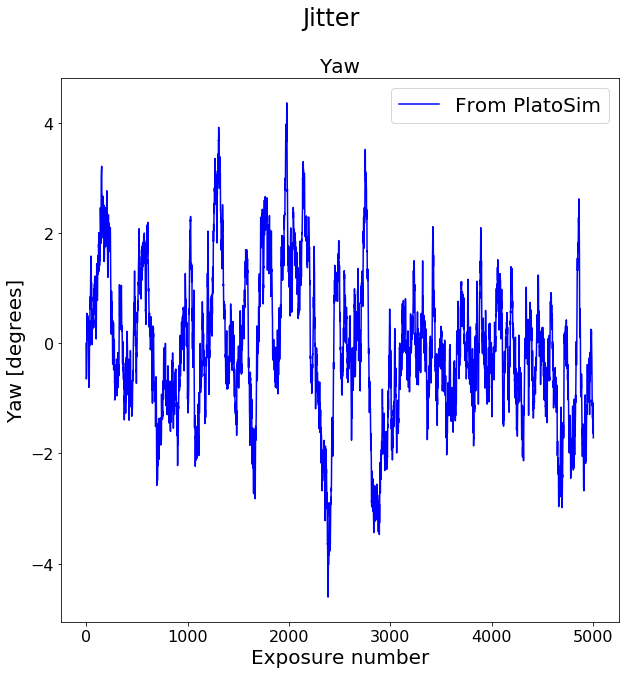

In [25]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

plt.plot(yaw, "b", label = "From PlatoSim")




########
# Layout
########

plt.suptitle("Jitter", fontsize = 24)
plt.title("Yaw", fontsize = 20)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("Exposure number", fontsize = 20)
plt.ylabel("Yaw [degrees]", fontsize = 20)

Text(0, 0.5, 'PSD')

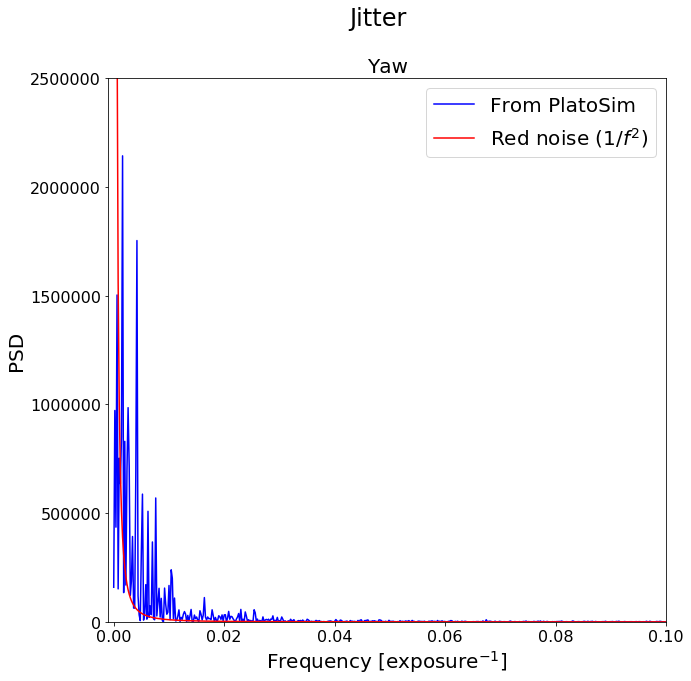

In [31]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

fs = 1
xF = np.fft.fft(yaw)
N = len(xF)
xF = xF[0:int(N//2)]
fr = np.linspace(0,fs/2,int(N//2))

plt.plot(fr, abs(xF)**2, "b", label = "From PlatoSim")



###########
# Red noise
###########

frNonZero = fr[fr != 0]
redNoise = 1 / frNonZero**2

plt.plot(frNonZero, redNoise, "r", label = "Red noise ($1 / f^2)$")



########
# Layout
########

plt.xlim([-0.001, 0.1])
plt.ylim([0, 2500000])

plt.suptitle("Jitter", fontsize = 24)
plt.title("Yaw", fontsize = 20)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("Frequency [exposure$^{-1}$]", fontsize = 20)
plt.ylabel("PSD", fontsize = 20)

### Pitch

Text(0, 0.5, 'Pitch [degrees]')

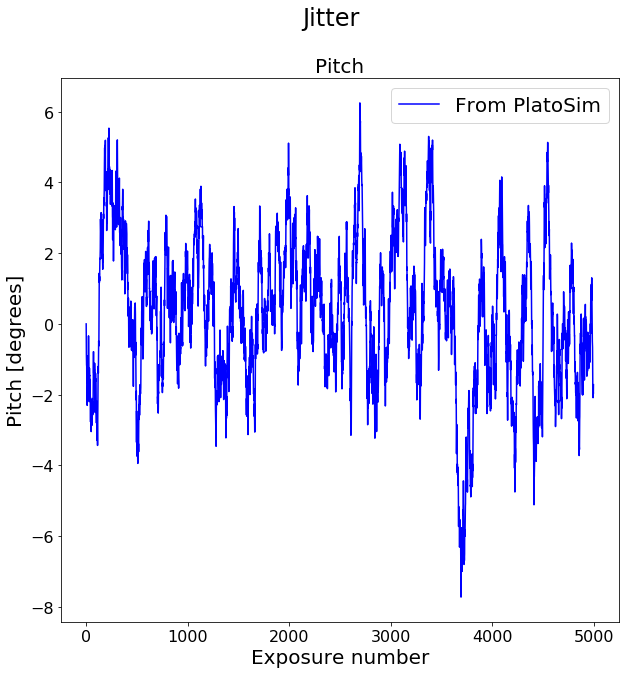

In [27]:
fig = plt.figure(figsize = (10, 10))



###############
# From PlatoSim
###############

ax = fig.add_subplot(1, 1, 1)
plt.plot(pitch, "b", label = "From PlatoSim")




########
# Layout
########

plt.suptitle("Jitter", fontsize = 24)
plt.title("Pitch", fontsize = 20)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("Exposure number", fontsize = 20)
plt.ylabel("Pitch [degrees]", fontsize = 20)

Text(0, 0.5, 'PSD')

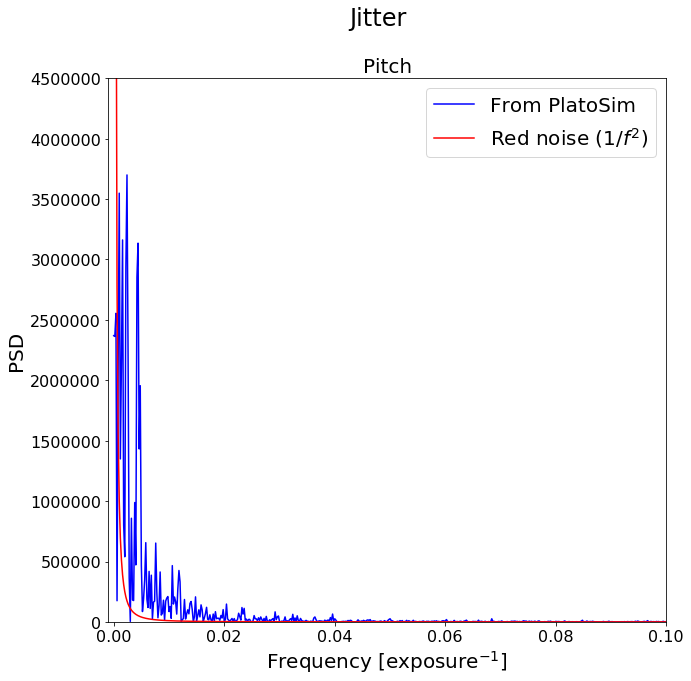

In [28]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

fs = 1
xF = np.fft.fft(pitch)
N = len(xF)
xF = xF[0:int(N//2)]
fr = np.linspace(0,fs/2,int(N//2))

plt.plot(fr, abs(xF)**2, "b", label = "From PlatoSim")



###########
# Red noise
###########

frNonZero = fr[fr != 0]
redNoise = 1 / frNonZero**2

plt.plot(frNonZero, redNoise, "r", label = "Red noise ($1 / f^2)$")



########
# Layout
########

plt.xlim([-0.001, 0.1])
plt.ylim([0, 4500000])

plt.suptitle("Jitter", fontsize = 24)
plt.title("Pitch", fontsize = 20)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("Frequency [exposure$^{-1}$]", fontsize = 20)
plt.ylabel("PSD", fontsize = 20)

### Roll

Text(0, 0.5, 'Roll [degrees]')

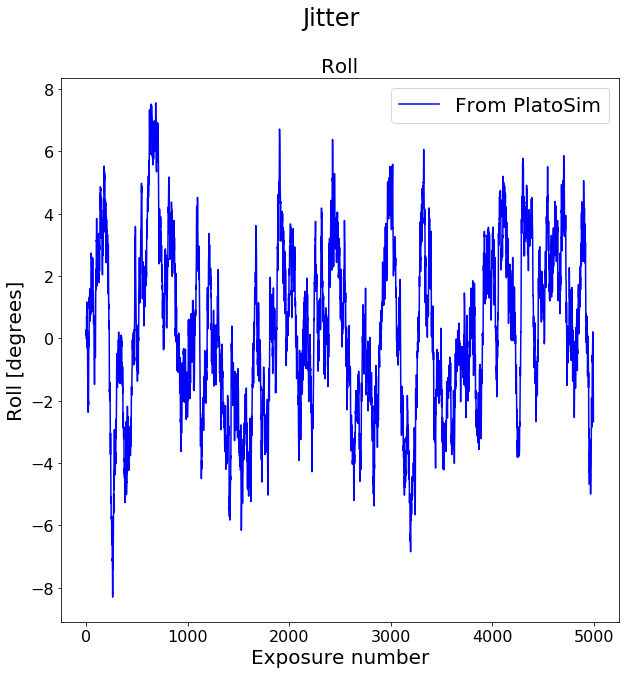

In [29]:
fig = plt.figure(figsize = (10, 10))



###############
# From PlatoSim
###############

ax = fig.add_subplot(1, 1, 1)
plt.plot(roll, "b", label = "From PlatoSim")




########
# Layout
########

plt.suptitle("Jitter", fontsize = 24)
plt.title("Roll", fontsize = 20)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("Exposure number", fontsize = 20)
plt.ylabel("Roll [degrees]", fontsize = 20)

Text(0, 0.5, 'PSD')

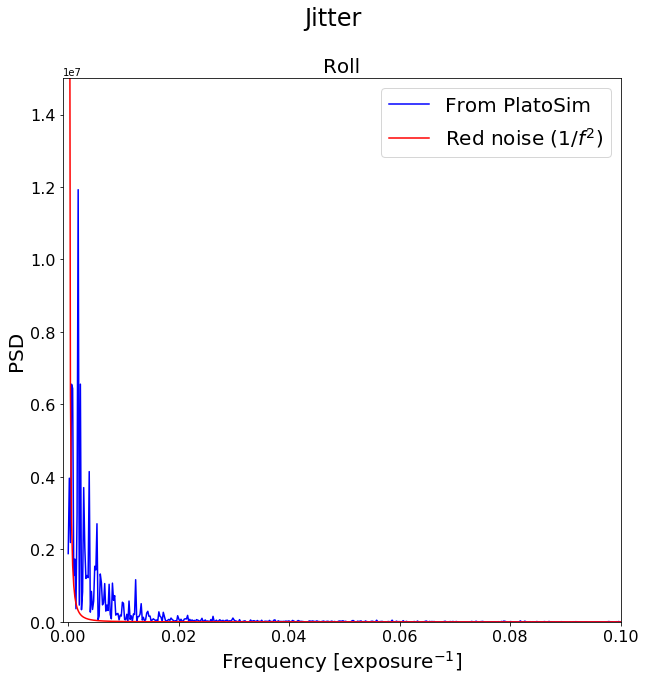

In [30]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

fs = 1
xF = np.fft.fft(roll)
N = len(xF)
xF = xF[0:int(N//2)]
fr = np.linspace(0,fs/2,int(N//2))

plt.plot(fr, abs(xF)**2, "b", label = "From PlatoSim")



###########
# Red noise
###########

frNonZero = fr[fr != 0]
redNoise = 1 / frNonZero**2

plt.plot(frNonZero, redNoise, "r", label = "Red noise ($1 / f^2)$")



########
# Layout
########

plt.xlim([-0.001, 0.1])
plt.ylim([0, 15000000])

plt.suptitle("Jitter", fontsize = 24)
plt.title("Roll", fontsize = 20)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("Frequency [exposure$^{-1}$]", fontsize = 20)
plt.ylabel("PSD", fontsize = 20)